# NYC Airbnb Price Category Classification Model Comparisons

## Overview


In this capstone project, I will be using the NYC Airbnb Listings dataset to define a machine learning problem, explore and prepare the data, and train, test, evaluate and improve a traditional machine learning model. Then, I will apply a neural network to the same problem and compare the two approaches. 

In both cases, I will be solving a supervised learning binary classification problem by predicting one of two possible class labels: whether an Airbnb is classified as high-priced or low-priced.

> **Note:** This project was completed as part of Cornell Tech's Break Through Tech program during the Machine Learning Foundations course. The project prompt, dataset, and overall workflow were provided by the program, while the implementation, analysis, modeling, and evaluation were done as part of the course.

## Imports

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

## Loading the Dataset

**Airbnb NYC Listings Data** (`airbnbListingsData.csv`):

This data set contains information about Airbnb listings in New York City.

The dataset includes a `price_category` column that classifies each listing as either **high price** or **low price** based on whether the price falls above or below the 75th percentile of all listing prices.

Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`.

The following cell loads the dataset and saves it to a Pandas dataframe.

In [ ]:
# File paths for data set
airbnb_filename = os.path.join(os.getcwd(), "airbnbListingsData.csv")

# Load chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Defining the ML Problem

**Problem:** Develop a model that predicts whether an Airbnb is "high priced" or "low priced" based on the 75th percentile of all prices

**Label:** `price_category`

Creating a model that accurately classifies Airbnbs by price allows consumers to select a listing based on their budget and needs. The model could also be integrated into a recommendation system for consumers when browsing for Airbnb listings that fall into a specific price range.

A reliable model decreases the chances of incorrectly classified listings, which in turn allow hosts to connect with guests whose budgets align with their Airbnbs and even saves consumers' time and money.

## Exploratory Data Analysis

### Class Imbalance

The following cell examines the distribution of the label column `price_category` to determine whether class imbalance is present.

The visualization highlights that there are many more low-priced Airbnbs than high-priced Airbnbs.

(28022, 51)
price_category
low     20785
high     7237
Name: count, dtype: int64


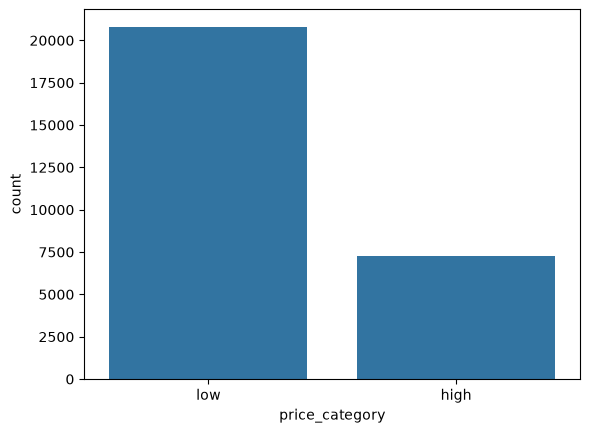

In [ ]:
# Print the dimensions of the dataset
print(df.shape) # 28022 rows, 51 columns

# Print the counts of each value in 'price_category'
print(df["price_category"].value_counts()) # no missing values in this column (20785 + 7237 = 28022)

# Visualize any class imbalance
sns.countplot(data = df, x = 'price_category')
plt.show()

### Inspecting and Selecting Features

By printing the dataset's columns, I examine the features that seem most relevant to predict the label.

In [4]:
print("COLUMNS:")
print(df.columns)

COLUMNS:
Index(['name', 'description', 'neighborhood_overview', 'host_name',
       'host_location', 'host_about', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_group_cleansed', 'room_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_score

### Features to Explore:
- `host_is_superhost`
- `host_identity_verified`
- `neighbourhood_group_cleansed`
- `room_type`
- `accommodates`
- `bathrooms`
- `bedrooms`
- `beds`
- `amenities`
- `price*` _(will not be used in modeling)_
- `review_scores_value`

### Feature Summaries
The `describe()` and `value_counts()` methods are used to generate different statistics for each feature.

I record what kind of variable the feature is (numerical or categorical), its minimum and maximum values (for numerical features), and its different categorical values (for categorical features).

In [11]:
# --- NOTES ---
# host_is_superhost -> categorical; all values true
# host_identity_verified -> categorical; all values true
# neighbourhood_group_cleansed -> categorical; Manhattan, Brooklyn, Queens, Bronx, Staten Island
# room_type -> categorical; entire home/apt, private room, shared room, hotel room
# accomodates -> numeric; 1-16
# bathrooms -> numeric; 0-8
# bedrooms -> numeric; 1-12
# beds -> numeric; 1-21
# amenities -> categorical; many unique lists with a mix of common and uncommon elements
# price -> numeric; $29-1000
# review_scores_value -> numeric; 0-5 
# price_category -> categorical; low, high

print("SHAPE:")
print(df.shape, "\n") # 28022, 51

print("--------------------------------------------")

print("DESCRIBE ENTIRE DATASET:")
print(df.describe(), "\n")

print("--------------------------------------------")

# Describe each feature and print their value counts

print("HOST_IS_SUPERHOST:")
print(df['host_is_superhost'].describe(), "\n") # All hosts are superhosts

print("--------------------------------------------")

print("HOST_IDENTITY_VERIFED:")
print(df['host_identity_verified'].describe(), "\n") # All hosts are verified

print("--------------------------------------------")

print("NEIGHRBOURHOOD_GROUP_CLEANSED:")
print(df['neighbourhood_group_cleansed'].describe(), "\n")
print("VALUE COUNTS OF", df['neighbourhood_group_cleansed'].value_counts(), "\n")
print("--------------------------------------------")

print("--------------------------------------------")

print("ROOM_TYPE:")
print(df['room_type'].describe(), "\n")
print("VALUE COUNTS OF", df['room_type'].value_counts(), "\n")

print("--------------------------------------------")

print("ACCOMODATES:")
print(df['accommodates'].describe(), "\n")
print("VALUE COUNTS OF", df['accommodates'].value_counts(), "\n")

print("--------------------------------------------")

print("BATHROOMS:")
print(df['bathrooms'].describe(), "\n")
print("VALUE COUNTS OF", df['bathrooms'].value_counts(), "\n")

print("--------------------------------------------")

print("BEDROOMS:")
print(df['bedrooms'].describe(), "\n")
print("VALUE COUNTS OF", df['bedrooms'].value_counts(), "\n")

print("--------------------------------------------")

print("BEDS:")
print(df['beds'].describe(), "\n")
print("VALUE COUNTS OF", df['beds'].value_counts(), "\n")

print("--------------------------------------------")

print("AMENITIES: ")
print(df['amenities'].describe(), "\n")
print("VALUE COUNTS OF", df['amenities'].value_counts(), "\n")

print("--------------------------------------------")

print("PRICES: ")
print(df['price'].describe(), "\n")
print("VALUE COUNTS OF", df['price'].value_counts(), "\n")

print("--------------------------------------------")

print("VALUE REVIEW SCORES: ")
print(df['review_scores_value'].describe(), "\n")
print("VALUE COUNTS OF", df['review_scores_value'].value_counts(), "\n")

print("--------------------------------------------")

print("PRICE_CATEGORY:")
print(df['price_category'].describe(), "\n")
print("VALUE COUNTS OF", df['price_category'].value_counts(), "\n")


SHAPE:
(28022, 51) 

--------------------------------------------
DESCRIBE ENTIRE DATASET:
       host_response_rate  host_acceptance_rate  host_listings_count  \
count        16179.000000          16909.000000         28022.000000   
mean             0.906901              0.791953            14.554778   
std              0.227282              0.276732           120.721287   
min              0.000000              0.000000             0.000000   
25%              0.940000              0.680000             1.000000   
50%              1.000000              0.910000             1.000000   
75%              1.000000              1.000000             3.000000   
max              1.000000              1.000000          3387.000000   

       host_total_listings_count  accommodates     bathrooms      bedrooms  \
count               28022.000000  28022.000000  28022.000000  25104.000000   
mean                   14.554778      2.874491      1.142174      1.329708   
std                   120.

### Missing Values

I note down how many missing values each feature has. This gives insight on how these features need to be handled later on.

In [13]:
# --- Missing Counts: ---
# host_is_superhost -> 0
# host_identity_verified -> 0
# neighbourhood_group_cleansed -> 0
# room_type -> 0
# accomodates -> 0
# bathrooms -> 0
# bedrooms -> 2918
# beds -> 1354
# amenities -> 0
# price -> 0
# review_scores_value -> 0
# price_category -> 0


# Print missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

name                                                5
description                                       570
neighborhood_overview                            9816
host_name                                           0
host_location                                      60
host_about                                      10945
host_response_rate                              11843
host_acceptance_rate                            11113
host_is_superhost                                   0
host_listings_count                                 0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bedrooms                                         2918
beds                        

### Feature Distributions

Visualizing the distributions of each feature allows us to see which categories and values appear more in the data.

`host_is_superhost` and `host_identity_verified` were removed from the analysis since every value in both features was `true`; this would provide no use to the model.

`amenities` is not plotted since most values are unique lists, and it would not be clear to display. The same applies for `price` since the sheer number of prices do not fit on the x-axis.

neighbourhood_group_cleansed
Manhattan        11639
Brooklyn         11258
Queens            4003
Bronx              838
Staten Island      284
Name: count, dtype: int64


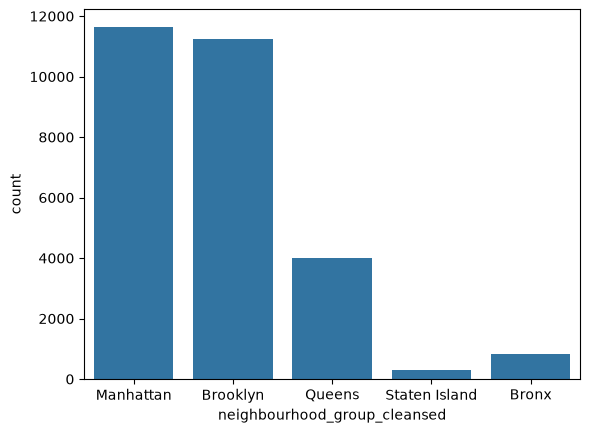

room_type
Entire home/apt    15604
Private room       11901
Shared room          380
Hotel room           137
Name: count, dtype: int64


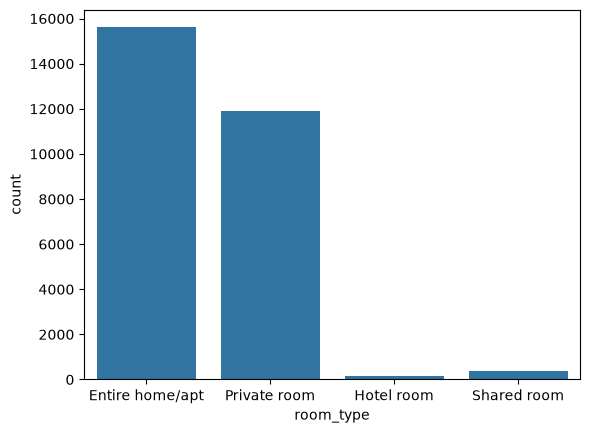

accommodates
2     13196
4      4445
1      3931
3      2809
6      1393
5      1173
8       404
7       276
10      145
12       79
16       70
9        45
11       22
13       15
14       13
15        6
Name: count, dtype: int64


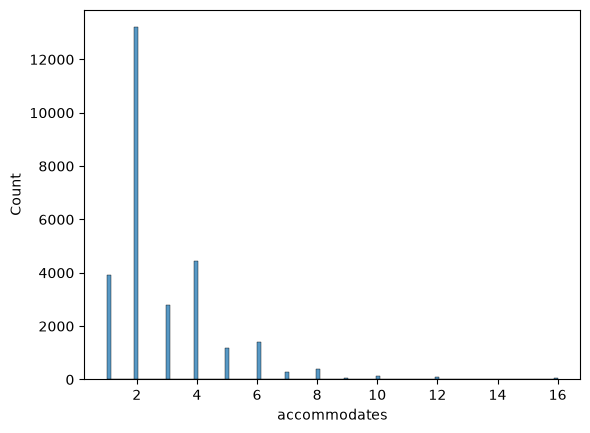

bathrooms
1.0    23783
2.0     2212
1.5     1273
2.5      293
3.0      197
0.0      126
3.5       60
4.0       43
4.5       16
5.0        7
5.5        4
6.0        3
8.0        2
6.5        1
7.0        1
7.5        1
Name: count, dtype: int64


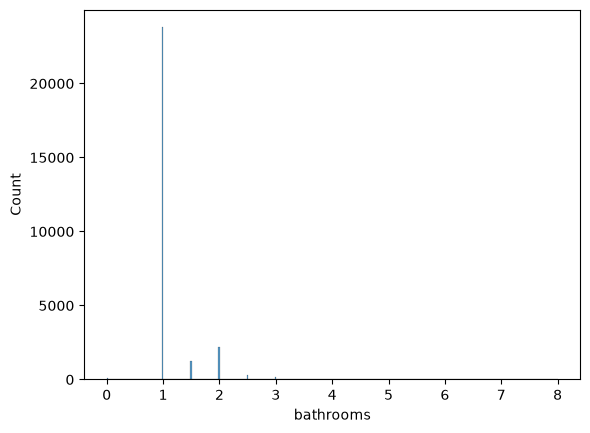

bedrooms
1.0     19235
2.0      4102
3.0      1319
4.0       329
5.0        81
6.0        21
7.0         7
8.0         6
9.0         2
11.0        1
12.0        1
Name: count, dtype: int64


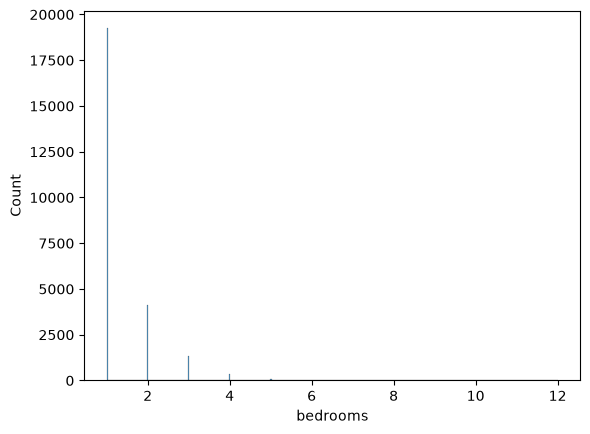

beds
1.0     16726
2.0      6082
3.0      2241
4.0       950
5.0       350
6.0       164
7.0        74
8.0        32
9.0        18
12.0       11
10.0        9
11.0        5
16.0        2
13.0        2
18.0        1
21.0        1
Name: count, dtype: int64


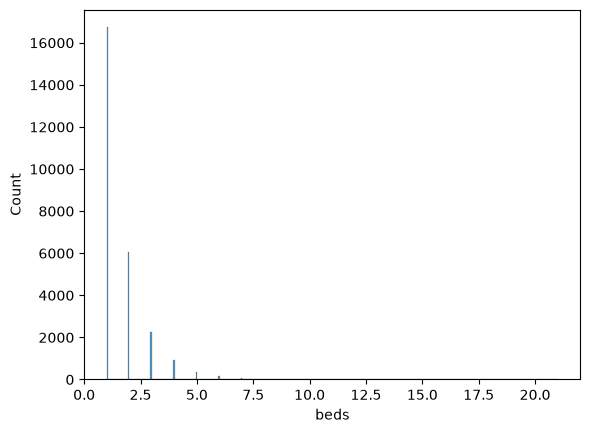

review_scores_value
5.00    7491
4.00    1342
4.50    1256
4.67    1018
4.75     833
        ... 
2.80       1
2.58       1
3.58       1
3.53       1
3.54       1
Name: count, Length: 164, dtype: int64


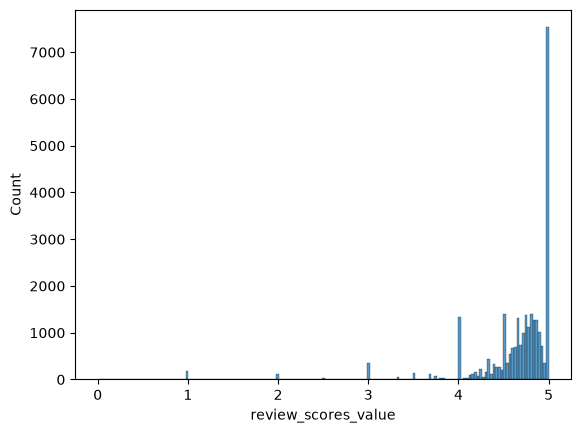

price_category
low     20785
high     7237
Name: count, dtype: int64


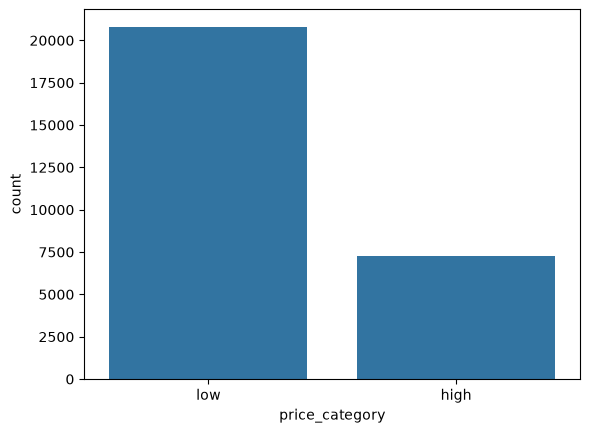

In [ ]:
# Print the value counts of each feature and plot their distributions

print(df["neighbourhood_group_cleansed"].value_counts())
sns.countplot(data = df, x = 'neighbourhood_group_cleansed')
plt.show()

print(df["room_type"].value_counts())
sns.countplot(data = df, x = 'room_type')
plt.show()

print(df["accommodates"].value_counts())
sns.histplot(data = df, x = 'accommodates')
plt.show()

print(df["bathrooms"].value_counts())
sns.histplot(data = df, x = 'bathrooms')
plt.show()

print(df["bedrooms"].value_counts())
sns.histplot(data = df, x = 'bedrooms')
plt.show()

print(df["beds"].value_counts())
sns.histplot(data = df, x = 'beds')
plt.show()

# Cannot plot amenities yet since almost each value is a unique list

# Cannot plot price since the number of prices do not fit on the x-axis

print(df["review_scores_value"].value_counts())
sns.histplot(data = df, x = 'review_scores_value')
plt.show()

print(df["price_category"].value_counts())
sns.countplot(data = df, x = 'price_category')
plt.show()

### Feature + Label Distributions

The following code reorders the categorical features' values to display them in the same order as they are in their plots.

Then all features' value counts are printed and visualized with the label. For each value a feature has, it gets compared to the instance where its corresponding Airbnb listing is classified as low-priced and high-priced.

In [ ]:
# Set the order of the values in the following categorical features
# to be consistent as the order they are displayed in when plotted

nyc_borough_order = ['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx']
df['neighbourhood_group_cleansed'] = pd.Categorical(
    df['neighbourhood_group_cleansed'],
    categories = nyc_borough_order,
    ordered = True
)

room_type_order = ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
df['room_type'] = pd.Categorical(
    df['room_type'],
    categories = room_type_order,
    ordered = True
)

price_category_order = ['low', 'high']
df['price_category'] = pd.Categorical(
    df['price_category'],
    categories = price_category_order,
    ordered = True
)

print(df['neighbourhood_group_cleansed'].value_counts(), "\n")
print(df['room_type'].value_counts(), "\n")
print(df['price_category'].value_counts(), "\n")

neighbourhood_group_cleansed
Manhattan        11639
Brooklyn         11258
Queens            4003
Bronx              838
Staten Island      284
Name: count, dtype: int64 

room_type
Entire home/apt    15604
Private room       11901
Shared room          380
Hotel room           137
Name: count, dtype: int64 

price_category
low     20785
high     7237
Name: count, dtype: int64 



price_category  neighbourhood_group_cleansed
low             Manhattan                       7383
                Brooklyn                        8900
                Queens                          3488
                Staten Island                    261
                Bronx                            753
high            Manhattan                       4256
                Brooklyn                        2358
                Queens                           515
                Staten Island                     23
                Bronx                             85
Name: count, dtype: int64


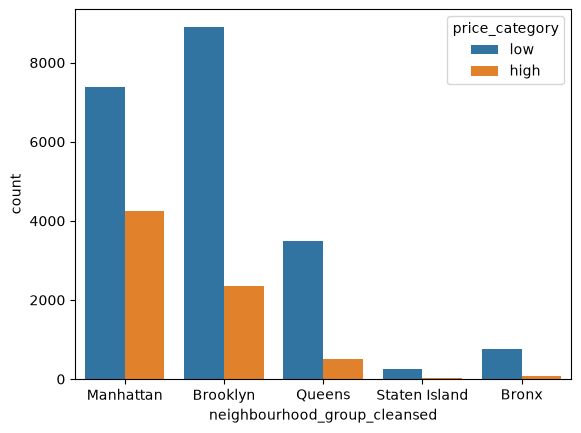

price_category  room_type      
low             Entire home/apt     9494
                Private room       10913
                Hotel room            31
                Shared room          347
high            Entire home/apt     6110
                Private room         988
                Hotel room           106
                Shared room           33
Name: count, dtype: int64


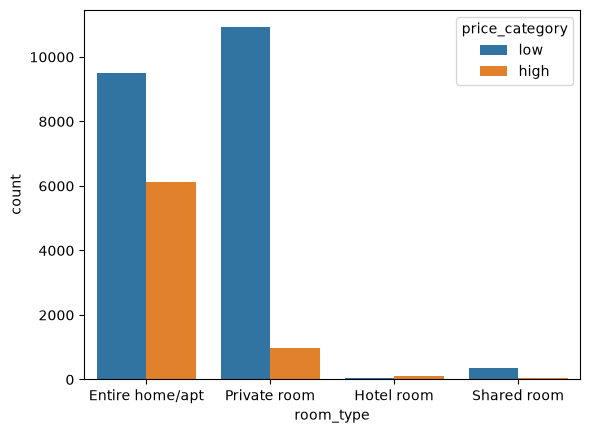

price_category  accommodates
low             1                3806
                2               11023
                3                2122
                4                2615
                5                 545
                6                 475
                7                  67
                8                  90
                9                  10
                10                 14
                11                  3
                12                 11
                14                  2
                16                  2
high            1                 125
                2                2173
                3                 687
                4                1830
                5                 628
                6                 918
                7                 209
                8                 314
                9                  35
                10                131
                11                 19
                12   

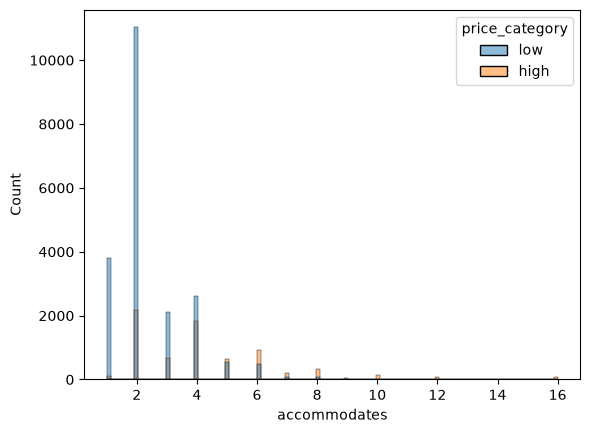

price_category  bathrooms
low             0.0            116
                1.0          18414
                1.5            929
                2.0           1135
                2.5             88
                3.0             87
                3.5              2
                4.0             11
                4.5              1
                6.0              2
high            0.0             10
                1.0           5369
                1.5            344
                2.0           1077
                2.5            205
                3.0            110
                3.5             58
                4.0             32
                4.5             15
                5.0              7
                5.5              4
                6.0              1
                6.5              1
                7.0              1
                7.5              1
                8.0              2
Name: count, dtype: int64


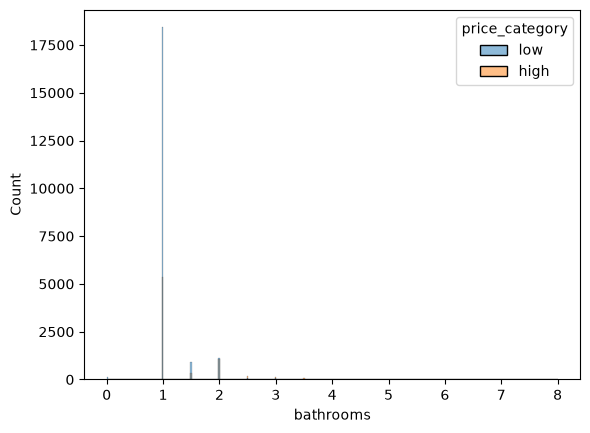

price_category  bedrooms
low             1.0         16141
                2.0          2086
                3.0           386
                4.0            52
                5.0             5
                7.0             1
                11.0            1
high            1.0          3094
                2.0          2016
                3.0           933
                4.0           277
                5.0            76
                6.0            21
                7.0             6
                8.0             6
                9.0             2
                12.0            1
Name: count, dtype: int64


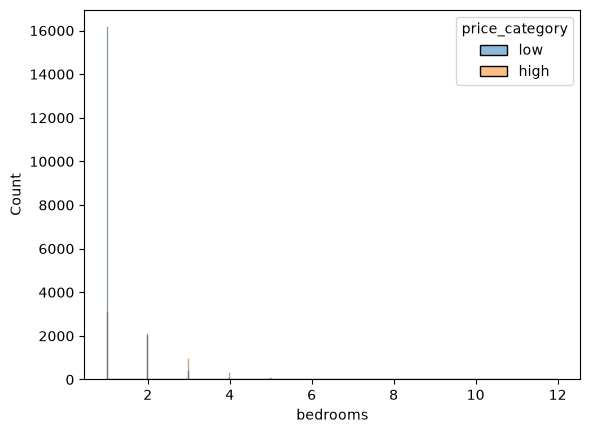

price_category  beds
low             1.0     14175
                2.0      3919
                3.0      1070
                4.0       367
                5.0       103
                6.0        46
                7.0         9
                8.0         8
                9.0         2
                10.0        3
                12.0        1
                21.0        1
high            1.0      2551
                2.0      2163
                3.0      1171
                4.0       583
                5.0       247
                6.0       118
                7.0        65
                8.0        24
                9.0        16
                10.0        6
                11.0        5
                12.0       10
                13.0        2
                16.0        2
                18.0        1
Name: count, dtype: int64


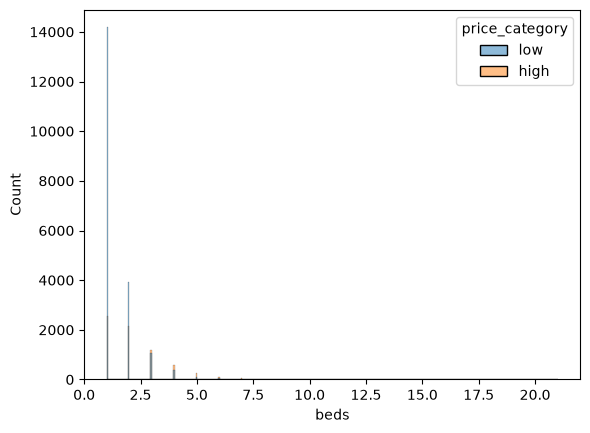

price_category  review_scores_value
low             0.00                      7
                1.00                    141
                1.50                      7
                1.67                      2
                2.00                     97
                                       ... 
high            4.96                     26
                4.97                     16
                4.98                      2
                4.99                      1
                5.00                   1850
Name: count, Length: 294, dtype: int64


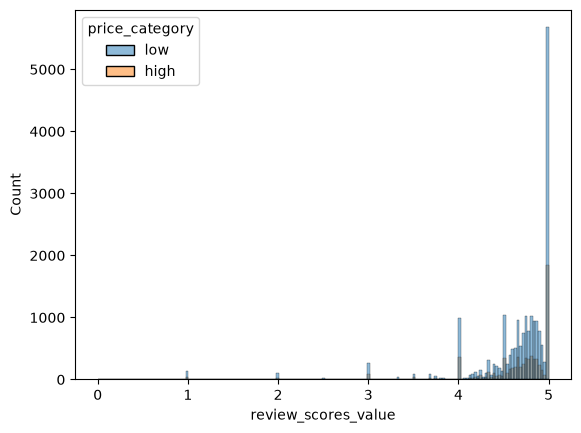

In [49]:
# Print the value counts and plot the distributions of each feature with the label

print(df.groupby('price_category')["neighbourhood_group_cleansed"].value_counts().sort_index())
sns.countplot(data = df, x = 'neighbourhood_group_cleansed', hue = 'price_category')
plt.show()

print(df.groupby('price_category')["room_type"].value_counts().sort_index())
sns.countplot(data = df, x = 'room_type', hue = 'price_category')
plt.show()

print(df.groupby('price_category')["accommodates"].value_counts().sort_index())
sns.histplot(data = df, x = 'accommodates', hue = 'price_category')
plt.show()

print(df.groupby('price_category')["bathrooms"].value_counts().sort_index())
sns.histplot(data = df, x = 'bathrooms', hue = 'price_category')
plt.show()

print(df.groupby('price_category')["bedrooms"].value_counts().sort_index())
sns.histplot(data = df, x = 'bedrooms', hue = 'price_category')
plt.show()

print(df.groupby('price_category')["beds"].value_counts().sort_index())
sns.histplot(data = df, x = 'beds', hue = 'price_category')
plt.show()

print(df.groupby('price_category')["review_scores_value"].value_counts().sort_index())
sns.histplot(data = df, x = 'review_scores_value', hue = 'price_category')
plt.show()


### Notable EDA Findings


Many features showed imbalances in their distributions, such as `neighborhood_group_cleansed`, where majority of Airbnbs are in Manhattan and Brooklyn, `room_type`, where majority of Airbnb listings are entire apartments/homes or private rooms, and `bedrooms`, where most listings have only 1 bedroom. This is something to consider moving forward, since there aren't enough representations for different Airbnbs and the model might perform better on well-represented groups than underrepresented groups.

The visualizations that displayed relationships between a feature and the label showed interesting results. I observed most "high priced" Airbnb listings are in Manhattan or Brooklyn and are entire homes or apartments. But many "low priced" Airbnbs also fall under those categories because of the large representations of data for those boroughs. But it is more clear that for the numerical features (e.g., bathrooms, bedrooms, beds), the higher their values, the more counts there are for "high priced" than "low priced". So these features may be useful predictors for the model.

In addition, there are also many outliers. For instance, in the feature `beds`, there are a few Airbnbs that have 10+ beds. And for the feature `bedrooms`, there are a few listings that have 7+ bedrooms. It needs to be considered whether to handle these outliers or to leave them. It makes sense for prices of the Airbnb to be expensive if there are more beds or rooms, so these values might actually be meaningful to use.

### Limitations and Ethical Considerations

It's important to reiterate that the imbalances in the dataset may affect model performance for underrepresented categories of Airbnb listings. Model predictions should be interpreted carefully, as features involving location and price may also reflect broader socioeconomic patterns.

Incorrect predictions from the model would harm both the consumers and the hosts. Users may be given suggestions that do not match their budgets, and hosts may miss opportunities to connect with potential customers if their listings are displayed inaccurately. The Airbnb company's overall reputation may be at risk as well if such inaccuracies become common and more impactful.


## Data Preparation

### Handling Missing Values

I examined the value counts and plotted the distributions of the `bedrooms` and `beds` features to reference back to later. These will be used as references to see how handling the missing values will affect the overall distributions of these features.

bedrooms
1.0     19235
2.0      4102
3.0      1319
4.0       329
5.0        81
6.0        21
7.0         7
8.0         6
9.0         2
11.0        1
12.0        1
Name: count, dtype: int64


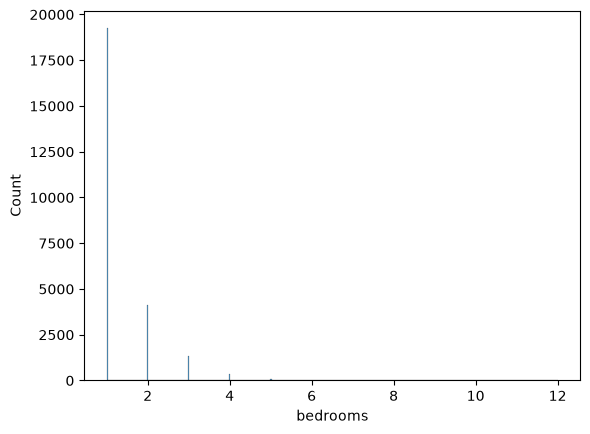

beds
1.0     16726
2.0      6082
3.0      2241
4.0       950
5.0       350
6.0       164
7.0        74
8.0        32
9.0        18
12.0       11
10.0        9
11.0        5
16.0        2
13.0        2
18.0        1
21.0        1
Name: count, dtype: int64


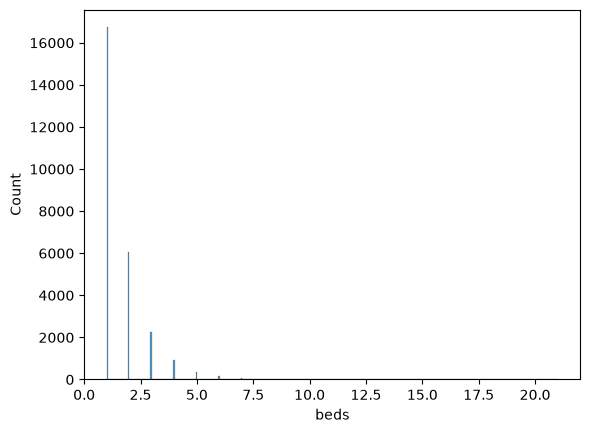

In [ ]:
# MISSING COUNTS:
# bedrooms --> 2918
# beds --> 1354

# Plot distributions before filling in missing values
print(df["bedrooms"].value_counts())
sns.histplot(data = df, x = 'bedrooms')
plt.show()

print(df["beds"].value_counts())
sns.histplot(data = df, x = 'beds')
plt.show()

I decided to impute the missing values with the mean value in `bedrooms` and `beds` since there are few missing values, so the new distributions would have minimal differences compared to the originals. Removing these rows would lead to losing data that could be used in model training.

1.0
2.0 

bedrooms
1.0     22153
2.0      4102
3.0      1319
4.0       329
5.0        81
6.0        21
7.0         7
8.0         6
9.0         2
11.0        1
12.0        1
Name: count, dtype: int64


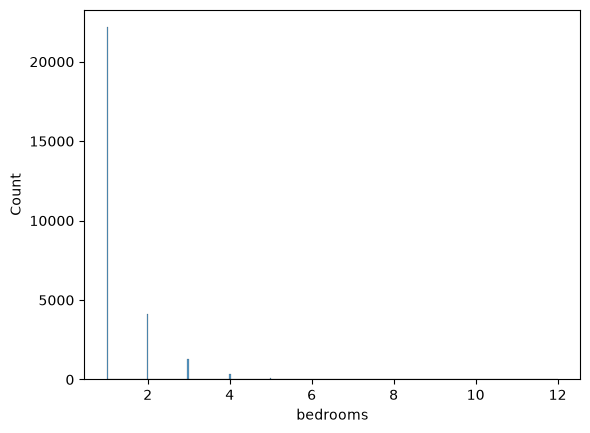

beds
1.0     16726
2.0      7436
3.0      2241
4.0       950
5.0       350
6.0       164
7.0        74
8.0        32
9.0        18
12.0       11
10.0        9
11.0        5
16.0        2
13.0        2
18.0        1
21.0        1
Name: count, dtype: int64


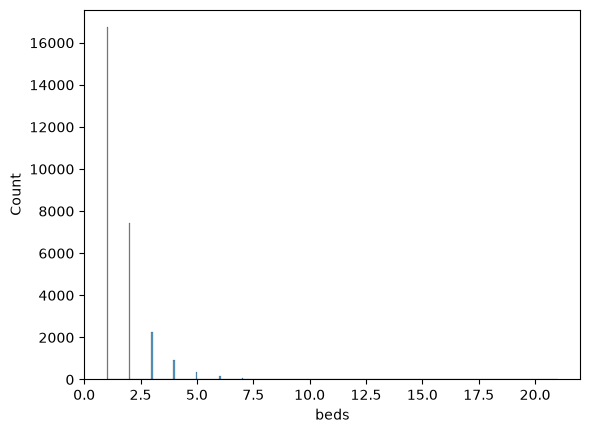

In [ ]:
# UPDATED COUNTS:
# bedrooms --> 19235 + 2918 = 22153
# beds --> 6082 + 1354 = 7436

# Replace missing values with means
mean_bedrooms = df['bedrooms'].mean().round()
print(mean_bedrooms) # ~1.33 --> 1.0
df['bedrooms'] = df['bedrooms'].fillna(mean_bedrooms)

mean_beds = df['beds'].mean().round()
print(mean_beds, "\n") # ~1.63 --> 2.0
df['beds'] = df['beds'].fillna(mean_beds)

# Visualize new distributions
print(df['bedrooms'].value_counts())
sns.histplot(data = df, x = 'bedrooms')
plt.show()

print(df['beds'].value_counts())
sns.histplot(data = df, x = 'beds')
plt.show()

### Handling `amenities`

Because `amenities` contains many lists with both common and unique values, I focused on the lengths of each list rather than the specific amenities themselves. In the following cell, I display the feature's distribution, along with its relationship with `price_category`. It can observed that the more amenities there are, the more likley it is for the Airbnb listing to be classified as 'high priced'.

count    28022.000000
mean       397.199379
std        213.412725
min          2.000000
25%        231.000000
50%        360.000000
75%        513.000000
max       1710.000000
Name: amenities_count, dtype: float64


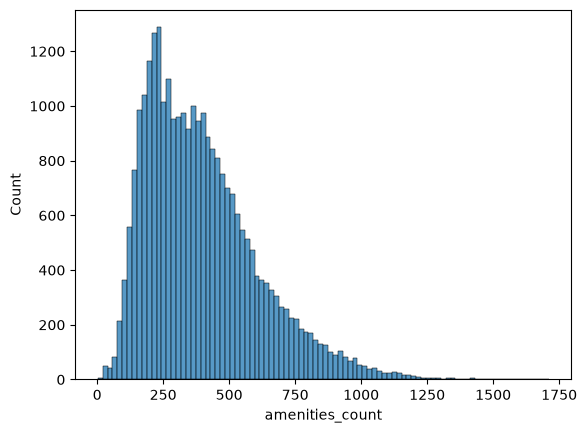

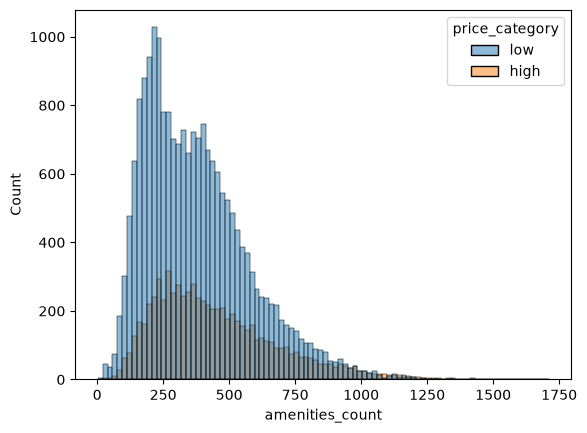

In [ ]:
# Create new amenities_count column, explore and plot the data
df['amenities_count'] = df['amenities'].apply(len)
print(df['amenities_count'].describe()) # Min-Max: 2-1710
sns.histplot(data = df, x = 'amenities_count')
plt.show()
sns.histplot(data = df, x = 'amenities_count', hue = 'price_category')
plt.show()

### One-Hot Encoding and Feature Selection
One-hot encoding was applied to the following categorical features to convert them into numerical values so the features can be used in ML models. It allows models to better learn how to understand categorical values without assuming an incorrect order of the categories.

Then I binarized `price_category` and created a new dataframe that contains only the features necessary to keep for the modeling phase.

In [56]:
# Use one-hot encoding on neighbourhood_group_cleansed and room_type
df_neighbourhood = pd.get_dummies(df['neighbourhood_group_cleansed'], prefix = 'neighbourhood_')
df_neighbourhood

df_room_type = pd.get_dummies(df['room_type'], prefix = 'room_')
df_room_type

# Binarize price_category
df_price_category = pd.get_dummies(df['price_category'], prefix = 'price_category_')
df_price_category


# Select features to keep
new_df = df[['neighbourhood_group_cleansed', 'room_type',
             'accommodates', 'bathrooms', 'bedrooms',
             'beds', 'review_scores_value', 'amenities_count', 'price_category']]

# Join and drop columns
new_df = new_df.join(df_neighbourhood)
new_df = new_df.join(df_room_type)
new_df = new_df.join(df_price_category)
new_df.drop(columns = ['neighbourhood_group_cleansed', 'room_type', 'price_category', 'price_category__low'], inplace = True)
new_df.rename(columns = {'price_category__high': 'price_category'}, inplace = True)

# Check the columns of the new dataframe
print(new_df.columns, "\n")
print(new_df['price_category'].value_counts(), "\n")
print(new_df['price_category'].unique())

Index(['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_value',
       'amenities_count', 'neighbourhood__Manhattan',
       'neighbourhood__Brooklyn', 'neighbourhood__Queens',
       'neighbourhood__Staten Island', 'neighbourhood__Bronx',
       'room__Entire home/apt', 'room__Private room', 'room__Hotel room',
       'room__Shared room', 'price_category'],
      dtype='str') 

price_category
False    20785
True      7237
Name: count, dtype: int64 

[False  True]


### Model Selection

A Decision Tree would be reasonable to use for this problem because it would be able to capture nonlinear relationships well, especially for a complex dataset such as this one. It utilizes hierarchical decision splits, so it would be able to go through different interactions between various features. It also would handle continuous numerical values, such as with `review_scores_value`, through threshold-based splits to split into different numeric categories (e.g., score < 3.5, score >= 3.5). In addition, since the categorical features are already one-hot encoded, the data fits well to be used with Scikit-learn's Decision Tree implementation.

## Training and Evaluating the Model

The features and the label must be separated before training the model.

In [57]:
# Create labeled examples from the dataset
y = new_df['price_category']
X = new_df.loc[:, new_df.columns != 'price_category']

print("Number of examples: " + str(X.shape[0]))
print("\nNumber of Features:" + str(X.shape[1]))
print(str(list(X.columns)))

Number of examples: 28022

Number of Features:15
['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_value', 'amenities_count', 'neighbourhood__Manhattan', 'neighbourhood__Brooklyn', 'neighbourhood__Queens', 'neighbourhood__Staten Island', 'neighbourhood__Bronx', 'room__Entire home/apt', 'room__Private room', 'room__Hotel room', 'room__Shared room']


Then, the data must be split into training and testing datasets.

During training, the model takes both the features and the label in the training data to learn its relationships and patterns. Then it analyzes the features in the test data and generates its predictions, which are then compared against the true labels in the test dataset to evaluate the model's performance.

In [58]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 123)

The function below takes in different parameters that will be applied to the Decision Tree model. It uses the test data to generate the accuracy score and F1 score so we can observe how well the model predicts the `price_category`.

In [60]:
# Train, test and evaluate the model
def train_test_DT(X_train, X_test, y_train, y_test, leaf, depth, crit = 'gini'):
    
    # Creating the Decision Tree object
    model = DecisionTreeClassifier(criterion = crit, max_depth = depth, min_samples_leaf = leaf)

    # Fit model to training data
    model.fit(X_train, y_train)
    
    # Make predictions on test data
    class_label_predictions = model.predict(X_test)

    # Get the accuracy and F1 scores
    acc_score = accuracy_score(y_test, class_label_predictions)
    f1_score_var = f1_score(y_test, class_label_predictions, average = 'binary')

    return acc_score, f1_score_var

Grid search cross-validation was implemented to find the best hyperparameter values for the model. The algorithm evaluated various combinations of `max_depth` and `min_samples_leaf` to find parameters that result in the highest F1 score.

Then the modeling function is called with the optimized parameters to see how they perform on the Decision Tree.

In [64]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
hyperparams_depth = [2**n for n in range(2,7)]
hyperparams_leaf = [25*2**n for n in range(0,4)]
param_grid={'max_depth':hyperparams_depth, 'min_samples_leaf':hyperparams_leaf}
print(param_grid)


print('Grid Search Started')
model = DecisionTreeClassifier()
grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'f1')
grid_search = grid.fit(X_train, y_train)
print('Grid Search Done')

best_param = grid_search.best_params_
best_score = grid_search.best_score_

print(best_param)
print(best_score)

{'max_depth': [4, 8, 16, 32, 64], 'min_samples_leaf': [25, 50, 100, 200]}
Grid Search Started
Grid Search Done
{'max_depth': 32, 'min_samples_leaf': 25}
0.5614893173317991


In [65]:
# Train and test the model with the optimized parameters
DT_acc, DT_f1 = train_test_DT(X_train, X_test, y_train, y_test, leaf = 25, depth = 32, crit = 'gini')

The model's accuracy and F1 score are displayed, as well as which features had the greatest influence in the model's predictions.

In [66]:
print(DT_acc) # 0.803 accuracy
print(DT_f1) # 0.569 F1 score

# Get the feature importances
model = DecisionTreeClassifier(max_depth = 32, min_samples_leaf = 25)
model.fit(X_train, y_train)
class_label_predictions = model.predict(X_test)
acc_score = accuracy_score(y_test, class_label_predictions)

feature_importances = model.feature_importances_
df_features = pd.DataFrame({'name': X_train.columns.values, 'imp': feature_importances})
df_sorted = df_features.sort_values('imp', ascending = False)
print(df_sorted)

0.8036160342571667
0.5692668927732847
                            name       imp
0                   accommodates  0.413688
5                amenities_count  0.146981
12            room__Private room  0.105640
6       neighbourhood__Manhattan  0.101073
1                      bathrooms  0.096564
4            review_scores_value  0.061213
2                       bedrooms  0.039971
7        neighbourhood__Brooklyn  0.011988
13              room__Hotel room  0.009381
3                           beds  0.008960
11         room__Entire home/apt  0.002852
14             room__Shared room  0.001126
8          neighbourhood__Queens  0.000413
10          neighbourhood__Bronx  0.000149
9   neighbourhood__Staten Island  0.000000


### Model Reflection

The model has an accuracy score of ~0.803 and an F1 score of ~0.569. It was able to classify ~80% of the data correctly as low or high priced, but the F1 score suggests that imbalance skewed the predictions by some margin, and that hinders the performance on any minority class. Originally, the model had an accuracy score of ~0.811 and an F1 score of ~0.529, but upon adding `amenities_count` and tuning the hyperparameters, the F1 score improved.

As for the feature importances, we can see that `accommodates` has the biggest impact on the model, followed by `amenities_count`, `room_Private room`, and `neighbourhood_Manhattan`.

It is important to reiterate that the model has limitations with underrepresented groups. Future models could address class imbalance with more depth, collect more samples for these groups, or evaluate model performance across the underrepresented groups to ensure more consistent predictions.

---
## Training and Evaluating a Neural Network


### Preparing Data for the Neural Network

Scaled versions of the training and test data were created since neural network require all input features to be numeric and scaled, otherwise the model may train less effectively and have difficulty learning meaningful patterns.




In [67]:
# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Defining the Model Architecture

The following cell constructs the neural network model with an input layer, three hidden layers, and one output layer.

I chose to use 3 hidden layers with units 64, 32, and 16 as they provide enough capacity for the neural network to learn complex patterns and nonlinear relationships. These values were selected as part of the trial and error process and are able to be adjusted later on in the modeling process. I experimented with 4 hidden layers, but keeping 3 yielded better results.

The `relu` activation function was applied because it sets negative activations to 0 and allows the model to focus more on stronger patterns from positive activations.

The output layer has 1 unit because we are dealing with a binary classification problem, so the output would signify whether an Airbnb is high priced or low priced.

The `sigmoid` activation function is used because it converts the value we get at at the output neuron into probabilities that determine whether an Airbnb is high or low priced, depending on whether the probability meets a certain threshold (typically 0.5) to become 0 or 1.


In [78]:
# Get the number of features in the training data
n_features = X_train_scaled.shape[1]
print(n_features)

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add it to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape = (n_features,), name = 'input')
nn_model.add(input_layer)

# Create the hidden layers and add them to the 'nn_model' object
hidden_layer_1 = keras.layers.Dense(units = 64, activation = 'relu', name = 'hl_1')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units = 32, activation = 'relu', name = 'hl_2')
nn_model.add(hidden_layer_2)

hidden_layer_3 = keras.layers.Dense(units = 16, activation = 'relu', name = 'hl_3')
nn_model.add(hidden_layer_3)

# Create the output layer and add it to the 'nn_model' object
output_layer = keras.layers.Dense(units = 1, activation = 'sigmoid', name = 'output')
nn_model.add(output_layer)

# Print the model's summary
nn_model.summary()

15


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hl_1 (Dense)                    │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hl_3 (Dense)                    │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

### Training Configuration

The stochastic gradient descent (SGD) optimizer is used to iteratively update the neural network's weights during training. The learning rate is 0.01 because this value allows for steady loss minimization and stable training.

In [79]:
sgd_optimizer = keras.optimizers.SGD(learning_rate = 0.01)

Binary cross-entropy was selected as a loss function since this is a binary classification problem. It takes the difference between the predicted probabilities and true outcomes, and provides feedback that helps improve the model.

In [80]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits = False)

The model is compiled with the optimization and loss functions above and uses the 'accuracy' metric to report accuracy during training.

In [81]:
nn_model.compile(optimizer = sgd_optimizer, loss = loss_fn, metrics = ['accuracy'])

### Fitting the Model to the Training Data

This is a callback class provided by Break Through Tech that outputs information from the model while it is training.

In [82]:
# --- CODE PROVIDED BY BREAK THROUGH TECH ---
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


The model is fit to the training data and is split to reserve a portion of the training data as a validation dataset.

After each of the 200 epochs, the model is evaluated on the validation data, allowing us to monitor how well it generalizes and detects signs of overfitting.

In [83]:
t0 = time.time() # start time

num_epochs = 200 

history = nn_model.fit(X_train_scaled, y_train, validation_split = 0.2, epochs = num_epochs, verbose=0,
                       callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)]) 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 200], Accuracy: 0.8137, Loss: 0.4001, Val_accuracy: 0.8160, Val_loss: 0.4025
Epoch [20/ 200], Accuracy: 0.8161, Loss: 0.3964, Val_accuracy: 0.8144, Val_loss: 0.4011
Epoch [30/ 200], Accuracy: 0.8172, Loss: 0.3944, Val_accuracy: 0.8142, Val_loss: 0.4001
Epoch [40/ 200], Accuracy: 0.8182, Loss: 0.3925, Val_accuracy: 0.8126, Val_loss: 0.3991
Epoch [50/ 200], Accuracy: 0.8181, Loss: 0.3908, Val_accuracy: 0.8137, Val_loss: 0.4010
Epoch [60/ 200], Accuracy: 0.8197, Loss: 0.3893, Val_accuracy: 0.8088, Val_loss: 0.4003
Epoch [70/ 200], Accuracy: 0.8179, Loss: 0.3885, Val_accuracy: 0.8114, Val_loss: 0.3979
Epoch [80/ 200], Accuracy: 0.8195, Loss: 0.3869, Val_accuracy: 0.8109, Val_loss: 0.3992
Epoch [90/ 200], Accuracy: 0.8213, Loss: 0.3859, Val_accuracy: 0.8103, Val_loss: 0.3990
Epoch [100/ 200], Accuracy: 0.8203, Loss: 0.3849, Val_accuracy: 0.8096, Val_loss: 0.4004
Epoch [110/ 200], Accuracy: 0.8198, Loss: 0.3842, Val_accuracy: 0.8109, Val_loss: 0.3983
Epoch [120/ 200], Accuracy: 0.

### Visualizing Training Performance
Two plots are created to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes
2. Training accuracy and validation accuracy over epochs, on the same axes

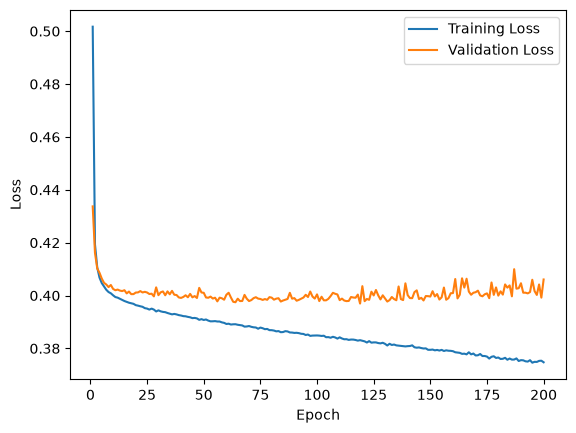

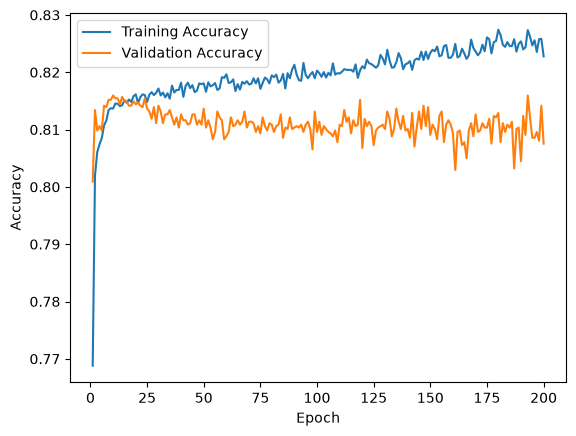

In [84]:
# Plot the training loss and validation loss over epochs
plt.plot(range(1, num_epochs + 1), history.history['loss'], label = 'Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label = 'Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Plot Analysis
For loss, the training curves highlight that the both training and validation losses decrease in the first few epochs, but as more epochs are run, the training loss continues to decrease but the validation loss begins to swing upwards and downwards between ~0.40 and ~0.41, remaining in that range.

For accuracy, the plots displayed similar results: both the training and validation accuracies increase in the beginning, but then only the training accuracy keeps an upward trend while the validation accuracy keeps bouncing up and down between a specific range (~0.805 - ~0.815).

Overall, the validation set's performance is always less than the training set's performance. This suggests there is some overfitting since the model matches more with the training data than the validation data.

### Evaluating the Model on the Test Set
The initial predictions of the model are returned as probabilites, so a threshold of 0.5 is applied where probabilities less than 0.5 convert to 0 (`low price`), and probabilities greater than or equal to 0.5 convert to 1 (`high price`).

In [85]:
# Generate predictions from the neural network using the scaled test data
# nn_model.predict() returns probabilities - apply a threshold of 0.5 to get class labels

predictions = nn_model.predict(X_test_scaled)
print(predictions, "\n")
predictions.shape # (8407, 1)
for i in range(0, 8407):
    if predictions[i] >= 0.5:
        predictions[i] = 1
    else:
        predictions[i] = 0

print(predictions)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
[[0.02995563]
 [0.01333523]
 [0.5670271 ]
 ...
 [0.53242517]
 [0.5708271 ]
 [0.01526609]] 

[[0.]
 [0.]
 [1.]
 ...
 [1.]
 [1.]
 [0.]]


### Displaying the Final Results

In [87]:
# Compute accuracy and F1 scores for the neural network
predictions = predictions.ravel()
NN_acc = accuracy_score(y_test, predictions)
NN_f1 = f1_score(y_test, predictions)

# Print the results
print(predictions)
print(NN_acc)
print(NN_f1)

[0. 0. 1. ... 1. 1. 0.]
0.8024265493041512
0.581506676744772


### Neural Network Reflection

The neural network's accuracy score is ~0.802 and the F1 score is ~0.582. The model is able to correctly classify about 80% of Airbnb listings, however the F1 score suggests it had trouble balancing the two price categories, most likely because of class imbalance.

To improve the model's performance, tuning the model's architecture or performing additional feature engineering are possible methods to apply to account for these issues.

## Comparing the Models and Reflecting

###  Results Summary
The following cell creates a summary table that displays each evaluation metric for both models side by side.

In [88]:
# Build a side-by-side comparison of the two models 
# using the metric variables created.
results = pd.DataFrame({
    'Metric': ['Accuracy:', 'F1 Score:'],
    'Decision Tree': [DT_acc, DT_f1],
    'Neural Network': [NN_acc, NN_f1]
})
print(results.to_string(index = False))

   Metric  Decision Tree  Neural Network
Accuracy:       0.803616        0.802427
F1 Score:       0.569267        0.581507


### Comparative Analysis

In terms of accuracy, both models performed very similarly to one another, with the Decision Tree winning by a difference of ~0.0012. But with the F1 scores, the neural network performed better with a difference of ~0.012.

If these models were developed for a client, I would not immediately deploy either since they both have room for improvement. At this stage however, I would lean more towards deploying the Decision Tree because it is a more reliable model. I reran the neural network and received different results each time. I did not set a seed for the model, so the network used unique values in each stage of training, which should be accounted for next time.

The Decision Tree still has a good accuracy score, a similar F1 score to the neural network, takes less time to run, and is easier to interpret. The DT does outweigh the NN in multiple fields, and it would be better to invest in a simpler model with better overall classification performance.

Future improvements for the models include:
- setting a seed for the neural network
- handling class imbalance
- diving deeper into different variables
  - specific amenities that might make an Airbnb more expensive (e.g., luxury items)
  - other variables exncluded from the original EDA (e.g., host-related features and reviews)
- splitting the datasets more equally between the Decision Tree and neural network, as the neural network utilized some training data for its validation set
- experimenting with the other methods of modeling, such as KNN